# Ames House Price Prediction — Data Understanding

**Problem:** Predict residential sale prices from property characteristics.

**Target:** SalePrice

**Task:** Supervised Regression

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

housing = fetch_openml(
    data_id=42165,
    as_frame=True
)

X = housing.data
y = housing.target


## Dataset Structure

In [41]:
X.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [42]:
X.shape, y.shape

((1460, 80), (1460,))

In [43]:
X.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
Length: 80, dtype: object

Python dtype is not necessarily the statistical type of a feature.

In [44]:
num_features = len(X.select_dtypes(include="number").columns)
non_num_features = len(X.select_dtypes(exclude="number").columns)

num_features, non_num_features

(37, 43)

## Target Analysis

In [45]:
y.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

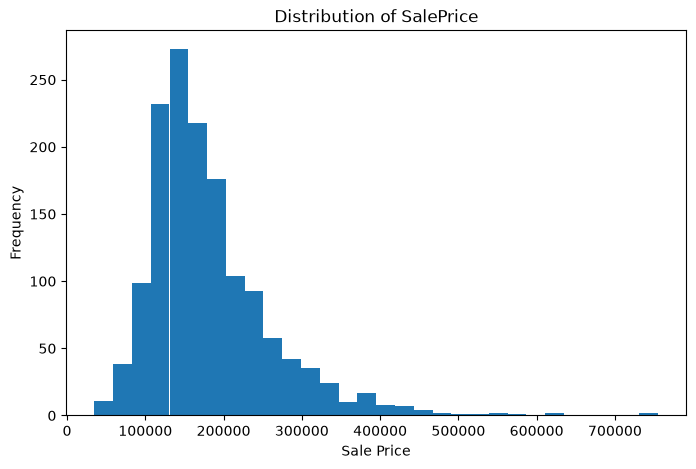

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.title("Distribution of SalePrice")
plt.show()

In [56]:
y.skew()

np.float64(1.8828757597682129)

In [64]:
q_1= y.quantile(0.25)
q_3 = y.quantile(0.75)
iqr = q_3 - q_1 
lower_fence = q_1 - 1.5 * iqr
upper_fence = q_3 + 1.5 * iqr
print(f"Q1 = {q_1}, Q3 = {q_3}, lower fence = {lower_fence}, upper fence = {upper_fence}")

Q1 = 129975.0, Q3 = 214000.0, lower fence = 3937.5, upper fence = 340037.5


In [66]:
outlier_candidate_count = y > upper_fence
outlier_candidate_count.sum()

np.int64(61)

In [67]:
(y < lower_fence).sum()

np.int64(0)

In [68]:
y[y > upper_fence]

11      345000
53      385000
58      438780
112     383970
151     372402
         ...  
1268    381000
1353    410000
1373    466500
1388    377500
1437    394617
Name: SalePrice, Length: 61, dtype: int64

In [70]:
X[y>upper_fence][["OverallQual","GrLivArea","Neighborhood","GarageCars"]]

,OverallQual,GrLivArea,Neighborhood,GarageCars
11,9,2324,NridgHt,3
53,9,1842,Veenker,3
58,10,2945,StoneBr,3
112,7,2696,CollgCr,3
151,8,1710,NridgHt,3
...,...,...,...,...
1268,8,3447,Crawfor,3
1353,8,3238,NoRidge,3
1373,10,2633,NoRidge,3
1388,9,1746,Gilbert,3


## Missing Values